<a href="https://colab.research.google.com/github/427paul/Data_Analysis/blob/main/BDA_%ED%95%99%ED%9A%8C%EC%9B%90_%EC%A1%B0%EB%B3%84%ED%99%9C%EB%8F%99_%EC%9D%B4%ED%83%88%EB%B0%A9%EC%A7%80_%EB%B6%84%EC%84%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BDA 11기 학회원 최종 과제: 조별활동 조편성 아이디어 및 전략 제시

**목표**: 학회 등 장기 교육 커뮤니티에서 발생하는 조별활동 이탈(Drop-out) 현상을 방지하기 위해, 기존 데이터를 탐색적 데이터 분석(EDA)과 기계학습(Machine Learning) 기법으로 다각도 분석합니다. 이를 통해 이탈 고위험군을 사전에 예측하고, 신청 단계에서 수집할 추가 데이터 제안 및 맞춤형 운영/조편성 전략을 도출합니다.

## 1. 라이브러리 호출 및 한글 폰트 설정
데이터 분석, 시각화, 머신러닝 모델링에 필요한 필수 라이브러리를 불러옵니다.

In [1]:
# 1️⃣ 나눔폰트 설치
!apt-get install -y fonts-nanum -qq

# 2️⃣ matplotlib 캐시 삭제
!rm -rf ~/.cache/matplotlib

# 3️⃣ 런타임 재시작 안내 출력
print("⚠️ 반드시 '런타임 → 런타임 다시 시작' 을 눌러주세요!")

Selecting previously unselected package fonts-nanum.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
⚠️ 반드시 '런타임 → 런타임 다시 시작' 을 눌러주세요!


In [1]:
# 관련 라이브러리 호출
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings("ignore")

# 한글 및 (-)부호 깨짐 현상 해결
plt.rcParams['font.family'] = 'NanumGothic' # Mac 사용자는 'AppleGothic'으로 변경
plt.rcParams['axes.unicode_minus'] = False

## 2. 데이터 로드 및 병합 (Data Loading & Merging)
`member.csv` (회원 정보), `group_study.csv` (조별활동 정보), `group_point.csv` (조별 활동 점수) 세 가지 데이터를 불러옵니다.
회원 정보를 식별할 수 있는 고유 키인 `member_id`와 `generation`(기수)을 기준으로 병합합니다.

In [2]:
# 데이터 로드
member_df = pd.read_csv("member.csv")
group_study_df = pd.read_csv("group_study.csv")
group_point_df = pd.read_csv("group_point.csv")

# member_id 타입을 문자열로 통일하여 병합
member_df['member_id'] = member_df['member_id'].astype(str)
group_study_df['member_id'] = group_study_df['member_id'].astype(str)
df = pd.merge(group_study_df, member_df, on=['member_id', 'generation'], how='left')

# 병합된 데이터 확인
df.head(3)

,member_id,generation,class_code,group_number,group_master,on_offline,group_leave,leave_point,excellent_group,excellent_group_master,...,company,major_data,class1,class2,class3,class4,marketing_agree,contents_agree,before_id,withdrawal
0,2024080003,8,4,14,False,오프라인,False,해당없음,False,False,...,NaN,True,4,NaN,NaN,NaN,True,True,NaN,False
1,2024080005,8,7,1,False,오프라인,False,해당없음,False,False,...,NaN,False,7,NaN,NaN,NaN,True,True,NaN,False
2,2024080007,8,5,7,False,온라인,False,해당없음,True,False,...,NaN,False,2,5,NaN,NaN,True,True,NaN,False


## 3. 데이터 전처리 및 파생변수 생성 (Data Preprocessing)
단순한 집계 및 머신러닝 학습에 적합하도록 변수들을 가공합니다.
1. **직업군 단순화**: 다양한 직업 데이터를 분석이 용이하도록 '학생', '직장인', '취준생', '기타' 4가지 카테고리로 묶습니다.
2. **나이(`age`) 파생변수**: 생년월일(`birthday`) 데이터를 연도 형식으로 변환하여 현재 기준의 나이를 산출합니다. 결측치는 중앙값으로 채웁니다.
3. **1개월차 활동 점수(`month1_point`)**: `group_point` 데이터에서 각 조의 활동 초기(1개월차) 평균 점수를 추출하여 메인 데이터프레임에 병합합니다. 이는 활동 극초반의 참여도가 이탈에 미치는 영향을 보기 위함입니다.

In [3]:
# 1. 직업군 단순화 함수 적용
def simplify_job(x):
    if pd.isna(x): return '미상'
    if '학생' in x or '대학생' in x or '대학원생' in x: return '학생'
    if '직장인' in x: return '직장인'
    if '취준생' in x: return '취준생'
    return '기타'

df['job_simplified'] = df['job'].apply(simplify_job)

# 2. 나이 파생변수 생성
df['birth_year'] = pd.to_numeric(df['birthday'].astype(str).str[:4], errors='coerce')
df['age'] = 2026 - df['birth_year'] # 현재 연도(2026) 기준 산출
df['age'] = df['age'].fillna(df['age'].median())

# 3. 1개월차 조별 점수 파생변수 병합
month1_pts = group_point_df[group_point_df['nth_month'] == 1].groupby(['generation', 'class_code', 'group_number'])['point'].mean().reset_index()
month1_pts.rename(columns={'point': 'month1_point'}, inplace=True)
df = pd.merge(df, month1_pts, on=['generation', 'class_code', 'group_number'], how='left')
df['month1_point'] = df['month1_point'].fillna(df['month1_point'].median())
df['group_master_int'] = df['group_master'].astype(int) # 모델링을 위해 숫자형 변환

## 4. 탐색적 데이터 분석 (EDA) - 기초 통계 시각화
주요 범주형/수치형 변수들이 이탈 여부(`group_leave`)와 어떤 관계를 맺고 있는지 시각화합니다.
- 온/오프라인 진행 방식별 이탈률
- 직업군별 이탈률
- 조장(리더) 여부에 따른 이탈률
- 1개월차 초기 활동 점수와 조 이탈 발생 관계

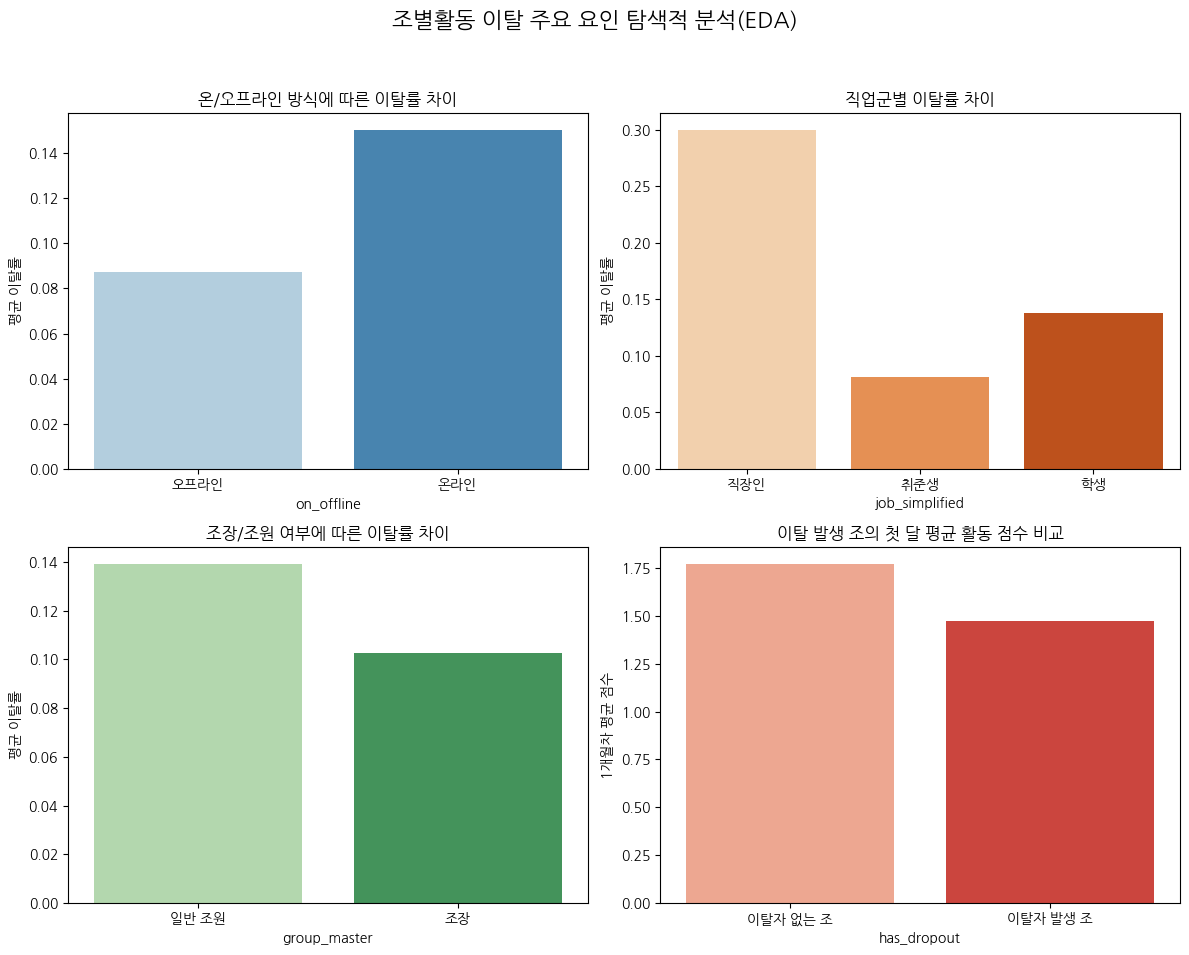

In [4]:
# 기초 통계 데이터 집계
on_offline_leave = df[df['on_offline'].isin(['온라인', '오프라인'])].groupby('on_offline')['group_leave'].mean().reset_index()
job_leave = df[df['job_simplified'].isin(['학생', '직장인', '취준생'])].groupby('job_simplified')['group_leave'].mean().reset_index()
master_leave = df.groupby('group_master')['group_leave'].mean().reset_index()

group_leaves = df.groupby(['generation', 'class_code', 'group_number'])['group_leave'].sum().reset_index()
group_leaves['has_dropout'] = group_leaves['group_leave'] > 0
group_pts_leaves = pd.merge(month1_pts, group_leaves, on=['generation', 'class_code', 'group_number'])
pts_leave = group_pts_leaves.groupby('has_dropout')['month1_point'].mean().reset_index()

# EDA 시각화
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('조별활동 이탈 주요 요인 탐색적 분석(EDA)', fontsize=16)

# ① 온/오프라인
sns.barplot(data=on_offline_leave, x='on_offline', y='group_leave', ax=axes[0,0], palette='Blues')
axes[0,0].set_title('온/오프라인 방식에 따른 이탈률 차이')
axes[0,0].set_ylabel('평균 이탈률')

# ② 직업군
sns.barplot(data=job_leave, x='job_simplified', y='group_leave', ax=axes[0,1], palette='Oranges')
axes[0,1].set_title('직업군별 이탈률 차이')
axes[0,1].set_ylabel('평균 이탈률')

# ③ 조장 여부
sns.barplot(data=master_leave, x='group_master', y='group_leave', ax=axes[1,0], palette='Greens')
axes[1,0].set_title('조장/조원 여부에 따른 이탈률 차이')
axes[1,0].set_xticks([0, 1])
axes[1,0].set_xticklabels(['일반 조원', '조장'])
axes[1,0].set_ylabel('평균 이탈률')

# ④ 초기(1개월차) 활동 점수
sns.barplot(data=pts_leave, x='has_dropout', y='month1_point', ax=axes[1,1], palette='Reds')
axes[1,1].set_title('이탈 발생 조의 첫 달 평균 활동 점수 비교')
axes[1,1].set_xticks([0, 1])
axes[1,1].set_xticklabels(['이탈자 없는 조', '이탈자 발생 조'])
axes[1,1].set_ylabel('1개월차 평균 점수')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### EDA 분석 인사이트
1. **오프라인보다 온라인의 이탈률이 약 2배 가량 높습니다.** (시공간적 제약이 없어 결속력이 떨어짐)
2. **직장인의 이탈률이 학생 대비 압도적으로 높습니다.** (본업과의 병행 한계)
3. **책임감이 주어지는 '조장' 포지션의 이탈률이 일반 조원보다 낮습니다.**
4. **조별활동 극초기(1개월차)의 평균 점수가 낮을수록 이탈 발생 확률이 매우 높습니다.**

## 5. 기계학습(Machine Learning) 모델링 준비 및 인코딩
앞선 EDA 인사이트를 통계적으로 검증하고, 보다 입체적인 타겟팅을 위해 머신러닝을 도입합니다.
범주형 변수를 컴퓨터가 이해할 수 있도록 One-Hot Encoding을 진행합니다.

In [5]:
# 범주형 데이터 One-hot Encoding 처리
df_encoded = pd.get_dummies(df, columns=['job_simplified', 'on_offline'], drop_first=False)

# 입력 변수(X)와 타겟 변수(y) 설정
features = ['age', 'group_master_int', 'month1_point'] + [c for c in df_encoded.columns if 'job_simplified_' in c or 'on_offline_' in c]
X = df_encoded[features].astype(float)
y = df_encoded['group_leave'].astype(int)

## 6. Random Forest: 이탈을 예측하는 핵심 요인 도출 (Feature Importance)
지도학습 모델인 Random Forest Classifier를 학습시켜, 수많은 변수들 중 **어떤 요인이 이탈 여부 분류에 가장 결정적인 역할을 하는지(변수 중요도)**를 산출합니다.

In [6]:
# Random Forest 학습
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, class_weight='balanced')
rf.fit(X, y)

# 변수 중요도 추출
feat_imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

feat_imp_df.head()

,Feature,Importance
2,month1_point,0.328681
11,on_offline_해당없음,0.195803
0,age,0.130542
8,on_offline_오프라인,0.122041
9,on_offline_온라인,0.049247


## 7. K-Means Clustering: 이탈 위험군 군집 분석
비지도학습 기법인 K-Means 클러스터링을 활용하여, 학회원들의 특성 데이터를 기반으로 비슷한 페르소나를 가진 그룹(k=5)으로 묶습니다.
이를 통해 단순히 '직장인'이라서 이탈하는 것이 아닌, 변수들이 결합된 **구체적인 위험 타겟 그룹의 패턴**을 식별합니다.

In [7]:
#이너셔 파악(군집의 개수 결정)
distance = []
for k in range(2,10):
  k_model = KMeans(n_clusters=k)
  k_model.fit(X)
  distance.append(k_model.inertia_)

<Axes: >

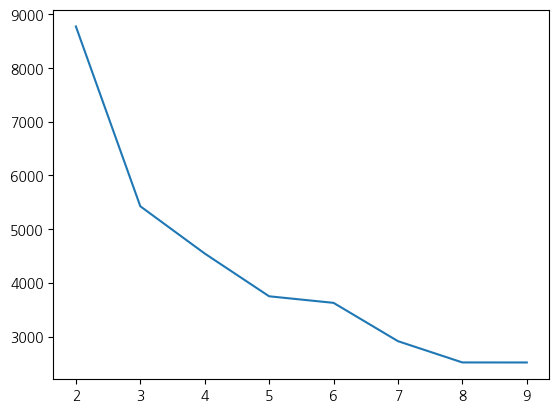

In [8]:
sns.lineplot(x=range(2,10),y=distance)
#군집의 수가 많아질수록 작은 그룹으로 데이터가 나눠지기 때문에 이너셔 값이 작아질 수밖에 없다
#급격하게 줄어드는 지점이 있는지 확인
#판단하기 어렵다.. -> 적절한 군집의 수는 얼마인가? -> 실루엣 계수 계산

In [9]:
#실루엣 계수
from sklearn.metrics import silhouette_score

In [10]:
silhouette = []
#군집의 개수를 변화시켜가며 실루엣 계수 계산
for k in range(2,10):
  k_model = KMeans(n_clusters = k)
  k_model.fit(X)
  labels = k_model.predict(X)
  silhouette.append(silhouette_score(X, labels))

<Axes: >

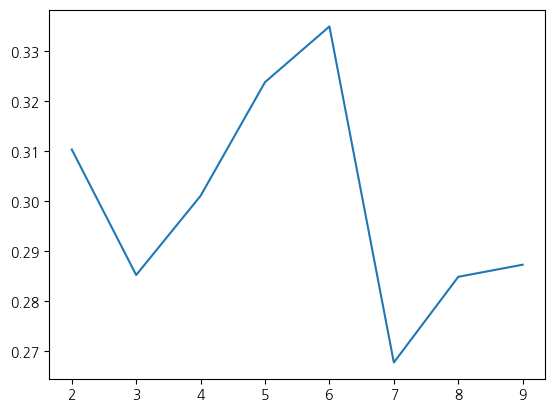

In [11]:
sns.lineplot(x=range(2,10),y=silhouette)

In [12]:
# 거리 기반 모델을 위한 데이터 표준화(Scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means 군집 분석 수행
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# 군집별 통계량 요약 분석
cluster_stats = df.groupby('cluster').agg(
    size=('member_id', 'count'),
    leave_rate=('group_leave', 'mean'),
    avg_age=('age', 'mean'),
    avg_month1_point=('month1_point', 'mean')
).reset_index()

cluster_cat = df.groupby('cluster').agg(
    top_job=('job_simplified', lambda x: x.value_counts().index[0]),
    top_offline=('on_offline', lambda x: x.value_counts().index[0])
).reset_index()

cluster_summary = pd.merge(cluster_stats, cluster_cat, on='cluster')
cluster_summary

,cluster,size,leave_rate,avg_age,avg_month1_point,top_job,top_offline
0,0,457,0.183807,24.588621,0.981346,학생,온라인
1,1,20,0.300000,29.900000,1.365000,직장인,온라인
2,2,319,0.087774,24.141066,3.239812,미상,오프라인
3,3,490,0.106122,24.679592,1.322369,학생,오프라인
4,4,49,0.081633,26.571429,1.206367,취준생,온라인


## 8. 머신러닝 분석 결과 시각화
Random Forest가 도출한 주요 변수와 K-Means가 분류한 위험 군집 결과를 차트로 확인합니다.

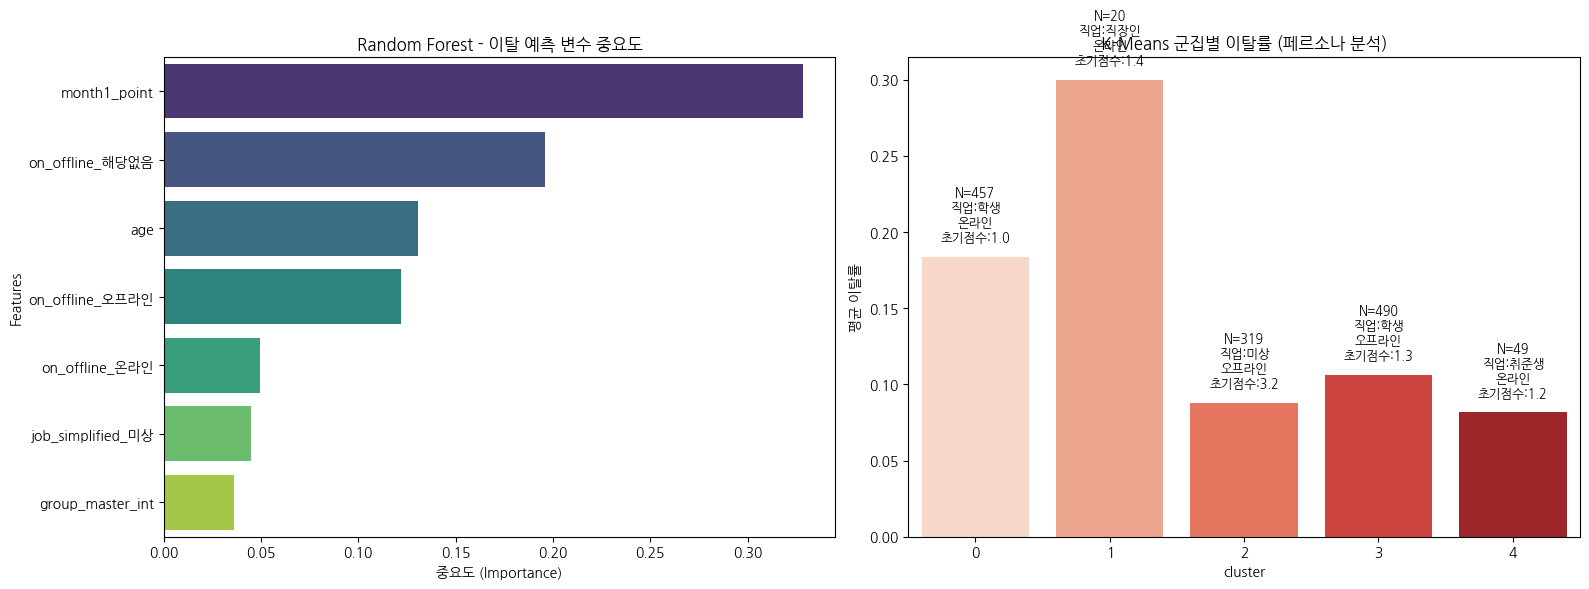

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ① Random Forest 변수 중요도
sns.barplot(data=feat_imp_df.head(7), x='Importance', y='Feature', ax=axes[0], palette='viridis')
axes[0].set_title('Random Forest - 이탈 예측 변수 중요도')
axes[0].set_xlabel('중요도 (Importance)')
axes[0].set_ylabel('Features')

# ② K-Means 군집별 이탈률
sns.barplot(data=cluster_summary, x='cluster', y='leave_rate', ax=axes[1], palette='Reds')
axes[1].set_title('K-Means 군집별 이탈률 (페르소나 분석)')
axes[1].set_ylabel('평균 이탈률')

# 군집별 속성 텍스트 표시
for i, p in enumerate(axes[1].patches):
    c = cluster_summary.iloc[i]
    text = f"N={int(c['size'])}\n직업:{c['top_job']}\n{c['top_offline']}\n초기점수:{c['avg_month1_point']:.1f}"
    axes[1].text(p.get_x() + p.get_width()/2., p.get_height() + 0.01, text, ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 9. 최종 결론 및 전략 제안 (Conclusion & Strategy)

**1. 분석 인사이트 도출**
* **초기 성과 지표의 중요성**: Random Forest 모델 검증 결과, 이탈 여부는 활동 시작 전의 정적 특성(직업, 나이 등)보다 **활동 개시 직후 1개월간 생성되는 동적 데이터(초기 활동 점수)에 훨씬 더 크게 좌우**됩니다.
* **타겟 군집의 명확화**: K-Means 군집 분석 결과, 같은 '학생'이더라도 오프라인 수강생은 이탈률이 낮고 안정적인 반면, **"1개월차 활동 점수가 저조한 온라인 수강 학생" 그룹이 가장 규모가 큰 잠재적 고위험군**으로 식별되었습니다. 또한 직장인 그룹은 소수이지만 독보적으로 높은 30%의 이탈률을 기록했습니다.

**2. 전략 제안**
* **[데이터 수집 제안] 학회원 심층 학습 성향 수집**
  - 온라인 매칭의 Fit을 높이기 위해 "주당 순수 스터디 투자 가능 시간", "선호하는 소통 매체(카톡, Zoom, Discord)", "학습 성향(타이트함 vs 여유로움)" 등을 신청 폼에서 수집해야 합니다.
* **[조편성 전략] 고위험군 분산 및 완충 매칭**
  - 이탈 초고위험군인 '직장인' 위주의 조 편성을 지양하고, 동기부여가 강한 취준생이나 학생 조장을 의도적으로 배치합니다.
  - 이탈률이 높은 '온라인 학생' 조에는 이전 기수 이수자 또는 학회 활동 우수자를 '페이스메이커(Pacemaker)'로 한 명씩 의도적으로 배치하는 알고리즘을 설계합니다.
* **[운영 전략] 머신러닝 기반 1개월차 Early Warning System 도입**
  - 1개월 차 종료 시점에 활동 점수가 하위 25% 인 조를 모델 알고리즘으로 즉시 식별하여 **'주의 대상'**으로 지정합니다.
  - 해당 조에는 운영진이 선제적으로 접근하여 맞춤형 인터벤션(온라인 커피챗 예산 우선 지원, 팀 노션 템플릿 제공, 애로사항 면담)을 실시하여 골든타임을 놓치지 않고 이탈을 방어합니다.